# 04 — Run T and VT

For each of the first `N_QUESTIONS` questions (in the fixed order from notebook 03), score A–D twice:
- **T**: transcript + question + options;
- **VT**: the same text + 64 silent video frames.

Each result is appended to `outputs/results.jsonl` as soon as it is computed. Questions already in the file are skipped,
so you can stop at any time, or raise `N_QUESTIONS` and rerun — only new questions are computed.

The run itself uses no answer keys; they are loaded only in the analysis section at the end.

In [1]:
N_QUESTIONS = None  # set to None to run all 598 questions (~10 h on CPU, ~1 min per question)

In [2]:
import sys, json, time, tomllib
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import qwen_omni as qo

CFG = tomllib.loads((ROOT / "configs/pilot.toml").read_text())
OUT = ROOT / "outputs/results.jsonl"
OUT.parent.mkdir(exist_ok=True)

questions = pd.read_parquet(ROOT / "data/processed/emotion_questions.parquet").head(N_QUESTIONS)
print(f"{len(questions)} questions selected")

598 questions selected


## Load the model (~18 GB RAM, a few minutes)

In [3]:
processor, model = qo.load(CFG["model_revision"])

[transformers] Model config: tts_text_start_token_id must be `None` or an integer within the vocabulary (between 0 and 8447), got 151860. This may result in unexpected behavior.
[transformers] Model config: tts_text_end_token_id must be `None` or an integer within the vocabulary (between 0 and 8447), got 151861. This may result in unexpected behavior.
[transformers] Model config: tts_text_pad_token_id must be `None` or an integer within the vocabulary (between 0 and 8447), got 151859. This may result in unexpected behavior.
[transformers] Model config: vision_start_token_id must be `None` or an integer within the vocabulary (between 0 and 8447), got 151652. This may result in unexpected behavior.
[transformers] Model config: vision_end_token_id must be `None` or an integer within the vocabulary (between 0 and 8447), got 151653. This may result in unexpected behavior.
[transformers] Model config: audio_start_token_id must be `None` or an integer within the vocabulary (between 0 and 8447

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1346 [00:00<?, ?it/s]

[transformers] Qwen2_5OmniThinkerForConditionalGeneration LOAD REPORT from: Qwen/Qwen2.5-Omni-7B
Key                                                                                                      | Status     |  | 
---------------------------------------------------------------------------------------------------------+------------+--+-
token2wav.code2wav_dit_model.transformer_blocks.{0...21}.attn.to_q.bias                                  | UNEXPECTED |  | 
token2wav.code2wav_dit_model.transformer_blocks.{0...21}.attn.to_k.bias                                  | UNEXPECTED |  | 
talker.model.layers.{0...23}.mlp.down_proj.weight                                                        | UNEXPECTED |  | 
token2wav.code2wav_bigvgan_model.resblocks.{0...17}.convs2.{0, 1, 2}.bias                                | UNEXPECTED |  | 
token2wav.code2wav_bigvgan_model.resblocks.{0...17}.activations.{0, 1, 2, 3, 4, 5}.act.alpha             | UNEXPECTED |  | 
talker.model.layers.{0...23}.mlp.up

## Show the exact prompt for the first question

In [4]:
first = questions.iloc[0]
print(qo.make_inputs(processor, qo.SYSTEM_PROMPT, qo.build_prompt(first))[1])

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Transcript of the dialogue in the clip:
(no dialogue)

Question: How does the man feel about knocking on the door?
A. The man expresses sadness that he won't come inside.
B. The man expresses fear that there might not be anyone inside.
C. The man expresses annoyance.
D. The man expresses nervousness.

Answer with the option's letter only.<|im_end|>
<|im_start|>assistant



## Run

In [5]:
done = {(r["question_id"], r["condition"]) for r in map(json.loads, OUT.open())} if OUT.exists() else set()
print(f"{len(done)} results already in {OUT.name}")

for q in tqdm(questions.itertuples(), total=len(questions), unit="question"):
    user_text = qo.build_prompt(q._asdict())
    for condition in ["T", "VT"]:
        if (q.question_id, condition) in done:
            continue
        t0 = time.time()
        if condition == "T":
            inputs, _ = qo.make_inputs(processor, qo.SYSTEM_PROMPT, user_text)
        else:
            video = ROOT / "data/raw/all_videos" / f"{q.movie_title}.mp4"
            frames, fps = qo.sample_frames(video, q.t_i, q.t_j, q.n_frames, CFG["max_pixels"])
            inputs, _ = qo.make_inputs(processor, qo.SYSTEM_PROMPT, user_text, frames, fps)
        r = qo.score_options(model, processor, inputs)
        row = {"order": q.order, "question_id": q.question_id, "condition": condition,
               **{f"prob_{L}": p for L, p in zip(qo.LETTERS, r["prob"])},
               "mass_on_letters": r["mass_on_letters"], "n_input_tokens": r["n_input_tokens"],
               "seconds": round(time.time() - t0, 1), "model_revision": CFG["model_revision"],
               "n_frames": q.n_frames if condition == "VT" else 0, "max_pixels": CFG["max_pixels"]}
        with OUT.open("a") as f:
            f.write(json.dumps(row) + "\n")

889 results already in results.jsonl


  0%|          | 0/598 [00:00<?, ?question/s]

qwen-vl-utils using decord to read video.
[h264 @ 0x3e2183c0] mmco: unref short failure


KeyboardInterrupt: 

## Results so far

In [6]:
results = pd.read_json(OUT, lines=True)
results.pivot(index=["order", "question_id"], columns="condition", values=["prob_A", "prob_B", "prob_C", "prob_D", "seconds"]).round(3)

prob_A        prob_B        prob_C        prob_D         \
condition              T     VT      T     VT      T     VT      T     VT   
order question_id                                                           
0     FH-76        0.024  0.002  0.262  0.942  0.159  0.020  0.555  0.037   
1     97rJU        0.680  0.666  0.056  0.080  0.250  0.245  0.014  0.009   
2     cP4lM        0.998  0.994  0.000  0.000  0.001  0.000  0.002  0.005   
3     XESWo        0.037  0.265  0.003  0.008  0.955  0.721  0.004  0.006   
4     6p7dK        0.315  0.162  0.667  0.184  0.016  0.641  0.002  0.013   
...                  ...    ...    ...    ...    ...    ...    ...    ...   
453   0qNJ5        0.117  0.107  0.005  0.024  0.018  0.256  0.861  0.614   
454   3nHht        0.034  0.040  0.118  0.203  0.768  0.553  0.081  0.203   
455   zmoeN        0.117  0.064  0.464  0.683  0.410  0.119  0.009  0.135   
456   8VrJu        0.329  0.179  0.155  0.379  0.290  0.334  0.226  0.108   
457   IZkOt        0.002    NaN  0.971    NaN  0.007    NaN  0.020    NaN   

                  seconds        
condition               T    VT  
order question_id                
0     FH-76           1.1  59.8  
1     97rJU           1.7  61.3  
2     cP4lM           4.2  64.7  
3     XESWo           2.2  61.8  
4     6p7dK           1.3  62.6  
...                   ...   ...  
453   0qNJ5           1.6  81.4  
454   3nHht           1.4  73.5  
455   zmoeN           1.1  74.3  
456   8VrJu           1.4  81.6  
457   IZkOt          12.6   NaN  

[458 rows x 10 columns]

## How did the model do?

Now we open the answer key (kept separate so it can't leak into the run).
- **prediction** = letter with the highest probability
- **confidence** = that highest probability
- **p_correct** = probability the model gave to the correct letter

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

keys = pd.read_parquet(ROOT / "data/processed/answer_keys.parquet")[["question_id", "correct_answer_key"]]
cues = pd.read_parquet(ROOT / "data/processed/emotion_questions.parquet")[["question_id", "cue_visual_any"]]
prob_cols = [f"prob_{L}" for L in qo.LETTERS]

df = pd.read_json(OUT, lines=True).merge(keys, on="question_id").merge(cues, on="question_id")
df["prediction"] = df[prob_cols].idxmax(axis=1).str[-1]
df["confidence"] = df[prob_cols].max(axis=1)
df["p_correct"] = df.apply(lambda r: r[f"prob_{r.correct_answer_key}"], axis=1)
df["correct"] = df["prediction"] == df["correct_answer_key"]
df[["order", "question_id", "condition", "correct_answer_key", "prediction", "confidence", "p_correct", "correct"]].round(3)

,order,question_id,condition,correct_answer_key,prediction,confidence,p_correct,correct
0,0,FH-76,T,D,D,0.555,0.555,True
1,0,FH-76,VT,D,B,0.942,0.037,False
2,1,97rJU,T,B,A,0.680,0.056,False
3,1,97rJU,VT,B,A,0.666,0.080,False
4,2,cP4lM,T,A,A,0.998,0.998,True
...,...,...,...,...,...,...,...,...
910,455,zmoeN,T,D,B,0.464,0.009,False
911,455,zmoeN,VT,D,B,0.683,0.135,False
912,456,8VrJu,T,D,A,0.329,0.226,False
913,456,8VrJu,VT,D,B,0.379,0.108,False


In [8]:
summary = df.groupby("condition").agg(
    n=("correct", "size"),
    accuracy=("correct", "mean"),
    mean_confidence=("confidence", "mean"),
    mean_p_correct=("p_correct", "mean"),
    conf_when_right=("confidence", lambda c: c[df.loc[c.index, "correct"]].mean()),
    conf_when_wrong=("confidence", lambda c: c[~df.loc[c.index, "correct"]].mean()),
)
summary.round(3)

,n,accuracy,mean_confidence,mean_p_correct,conf_when_right,conf_when_wrong
condition,,,,,,
T,458,0.533,0.755,0.499,0.809,0.693
VT,457,0.556,0.794,0.536,0.856,0.716


Same questions, T vs VT: did adding the video fix or break answers?

In [9]:
wide = df.pivot(index="question_id", columns="condition", values=["correct", "p_correct", "confidence"])
wide = wide.dropna()  # only questions that have both T and VT
print(f"{len(wide)} questions with both conditions")
pd.crosstab(wide["correct"]["T"].map({True: "T right", False: "T wrong"}),
            wide["correct"]["VT"].map({True: "VT right", False: "VT wrong"}))

457 questions with both conditions


VT,VT right,VT wrong
T,,
T right,208,35
T wrong,46,168


Accuracy split by whether the annotators said the answer needs a visual cue (face / body).

In [10]:
df.pivot_table(index="cue_visual_any", columns="condition", values="correct", aggfunc=["mean", "size"]).round(3)

mean        size     
condition           T     VT    T   VT
cue_visual_any                        
False           0.455  0.477   66   65
True            0.546  0.569  392  392

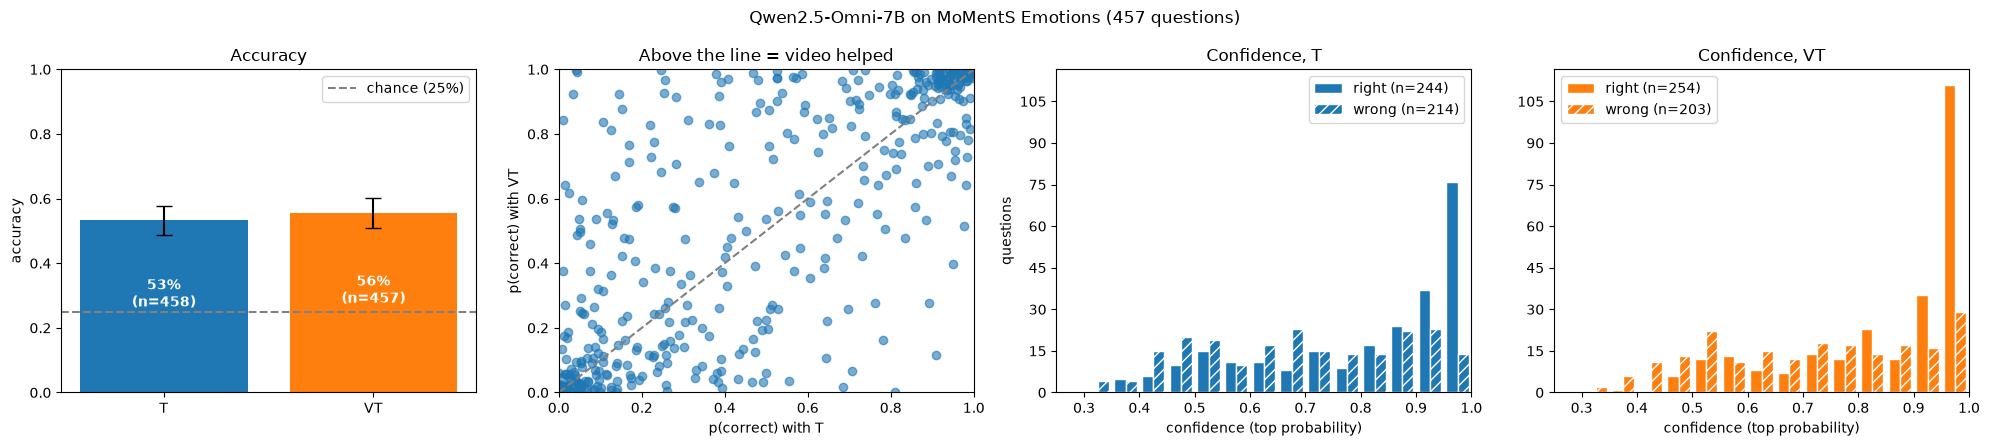

In [11]:
colors = {"T": "tab:blue", "VT": "tab:orange"}
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
axes[3].sharey(axes[2])  # same y scale for the two confidence panels

# 1. accuracy with a 95% interval (normal approximation), chance = 25%
ax = axes[0]
acc, n = summary["accuracy"], summary["n"]
err = 1.96 * (acc * (1 - acc) / n) ** 0.5
ax.bar(summary.index, acc, yerr=err, capsize=6, color=[colors[c] for c in summary.index])
ax.axhline(0.25, ls="--", c="gray", label="chance (25%)")
for i, (a, k) in enumerate(zip(acc, n)):
    ax.text(i, a / 2, f"{a:.0%}\n(n={k})", ha="center", color="white", fontweight="bold")
ax.set(ylim=(0, 1), ylabel="accuracy", title="Accuracy")
ax.legend()

# 2. probability on the correct answer, each dot is one question
ax = axes[1]
ax.scatter(wide["p_correct"]["T"], wide["p_correct"]["VT"], alpha=0.6)
ax.plot([0, 1], [0, 1], c="gray", ls="--")
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="p(correct) with T", ylabel="p(correct) with VT",
       title="Above the line = video helped")

# 3-4. confidence of right vs wrong answers, one panel per condition.
# Bars side by side per bin: right = filled, wrong = same color with hatching.
bins = [i / 20 for i in range(5, 21)]  # confidence is always >= 0.25
for ax, cond in zip(axes[2:], ["T", "VT"]):
    sub = df[df.condition == cond]
    right, wrong = sub.loc[sub.correct, "confidence"], sub.loc[~sub.correct, "confidence"]
    _, _, (bars_right, bars_wrong) = ax.hist(
        [right, wrong], bins=bins, color=[colors[cond]] * 2, edgecolor="white",
        label=[f"right (n={len(right)})", f"wrong (n={len(wrong)})"])
    for bar in bars_wrong:
        bar.set_hatch("///")
    ax.set(xlim=(0.25, 1), xlabel="confidence (top probability)", title=f"Confidence, {cond}")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend()
axes[2].set_ylabel("questions")

fig.suptitle(f"Qwen2.5-Omni-7B on MoMentS Emotions ({len(wide)} questions)")
fig.tight_layout()
fig.savefig(ROOT / "outputs/results.png", dpi=150)
plt.show()